# LightGBM — Prédiction des consommations énergétiques

## Sous-ensemble étudié
A voir plus tart


## Variables cibles

Le modèle prédit simultanément les cinq variables suivantes :

- `out.electricity.total.energy_consumption..kwh`
- `out.emissions.total.lrmer_mid_case_25..co2e_kg`
- `out.natural_gas.total.energy_consumption..kwh`
- `out.fuel_oil.total.energy_consumption..kwh`
- `out.propane.total.energy_consumption..kwh`


## Stratégies de stratification évaluées

### Stratification 1

Variables utilisées pour construire les strates :

- `in.geometry_floor_area`
- `in.vintage`
- `in.occupants`
- `in.heating_fuel`

### Stratification 2

Variables utilisées pour construire les strates :

- `in.occupancy_intensity`
- `in.vintage`
- `in.heating_fuel`

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import optuna
from sklearn.model_selection import KFold, StratifiedKFold

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import lightgbm as lgb

ROOT = Path().resolve().parent.parent
DATA_PROCESSED = ROOT / "data" / "processed"

X = pd.read_parquet(DATA_PROCESSED / "X.parquet")
Y = pd.read_parquet(DATA_PROCESSED / "Y.parquet")

metadata = pd.read_parquet(DATA_PROCESSED / "metadata_clean.parquet")
X_physical = pd.read_parquet(DATA_PROCESSED / "X_physical_engineered.parquet")



print(X.shape)
print(metadata.shape)
print(X_physical.shape)


(549971, 107)
(549971, 391)
(549971, 84)


In [ ]:
#construire un dataframe de stratification pour le split train/test



#===========================================================
# Stratification pour les features globales
#===========================================================
strat = pd.DataFrame(index=X.index)

strat["surface"] = X["in.geometry_floor_area"]
strat["vintage"] = X["in.vintage"]
strat["occupants"] = X["in.occupants"]
strat["heating"] = metadata["in.heating_fuel"].astype(str)


#===========================================================
# Stratification pour les features physiques
#===========================================================
strat_physical = pd.DataFrame(index=X_physical.index)

strat_physical["occupancy"] = X_physical["in.occupancy_intensity"]
strat_physical["vintage"] = X_physical["in.vintage"]
strat_physical["heating"] = metadata["in.heating_fuel"].astype(str)

In [ ]:
#faire des categories pour les variables continues pour la stratification


#===========================================================
# Catégorisation des variables globales continues pour stratification
#===========================================================

strat["surface_cat"] = pd.qcut(
    strat["surface"],
    q=4,
    labels=False,
    duplicates="drop"
)

strat["vintage_cat"] = pd.qcut(
    strat["vintage"],
    q=4,
    labels=False,
    duplicates="drop"
)

strat["occupants_cat"] = pd.qcut(
    strat["occupants"],
    q=3,
    labels=False,
    duplicates="drop"
)


#===========================================================
# Catégorisation des variables physiques continues pour stratification
#===========================================================

# Catégories de densité d'occupation
strat_physical["occupancy_cat"] = pd.qcut(
    strat_physical["occupancy"],
    q=4,
    labels=False,
    duplicates="drop"
)


# Catégories d'ancienneté du bâtiment
strat_physical["vintage_cat"] = pd.qcut(
    strat_physical["vintage"],
    q=4,
    labels=False,
    duplicates="drop"
)


# La variable chauffage est déjà catégorielle
strat_physical["heating_cat"] = (
    strat_physical["heating"]
    .astype("category")
    .cat.codes
)

In [ ]:

heating_map = {
    "Natural Gas": "Gas",
    "Electricity": "Electric",
    "Fuel Oil": "Oil",
    "Propane": "Oil",
    "Wood": "Other",
    "None": "Other",
    "Other Fuel": "Other"
}

strat["heating_clean"] = strat["heating"].map(heating_map)


#===========================================================
# Regroupement des types de chauffage
#===========================================================



strat_physical["heating"] = (
    strat_physical["heating"]
    .map(heating_map)
    .fillna("Other")
)


In [ ]:
print(strat["heating"].value_counts())
print(strat_physical["heating"].value_counts())


heating
Natural Gas    262274
Electricity    222954
Fuel Oil        25751
Propane         24446
Wood             8603
None             4051
Other Fuel       1892
Name: count, dtype: int64
heating
Gas         262274
Electric    222954
Oil          50197
Other        14546
Name: count, dtype: int64


In [ ]:

#===========================================================
# Création d'une classe de stratification finale
#===========================================================

#avec les features globales
strat["stratum"] = (
    strat["surface_cat"].astype(str)
    + "_"
    + strat["vintage_cat"].astype(str)
    + "_"
    + strat["occupants_cat"].astype(str)
    + "_"
    + strat["heating"]
)


#avec les features physiques
strat_physical["strata"] = (
    strat_physical["occupancy_cat"].astype(str)
    + "_"
    + strat_physical["vintage_cat"].astype(str)
    + "_"
    + strat_physical["heating_cat"].astype(str)
)

In [ ]:

group_sizes = strat["stratum"].value_counts()
group_sizes_physical = strat_physical["strata"].value_counts()

print(group_sizes.describe())
print(group_sizes_physical.describe())

count      336.000000
mean      1636.818452
std       2772.948449
min          4.000000
25%         83.500000
50%        327.000000
75%       1579.000000
max      18223.000000
Name: count, dtype: float64
count      112.000000
mean      4910.455357
std       7239.337562
min         63.000000
25%        274.250000
50%       1047.500000
75%       5980.750000
max      24514.000000
Name: count, dtype: float64


Nombre total de groupes : 336
Groupes avec moins de 2 observations : 0
Groupes avec moins de 5 observations : 1
Groupes avec moins de 10 observations : 4
Groupes avec moins de 20 observations : 11


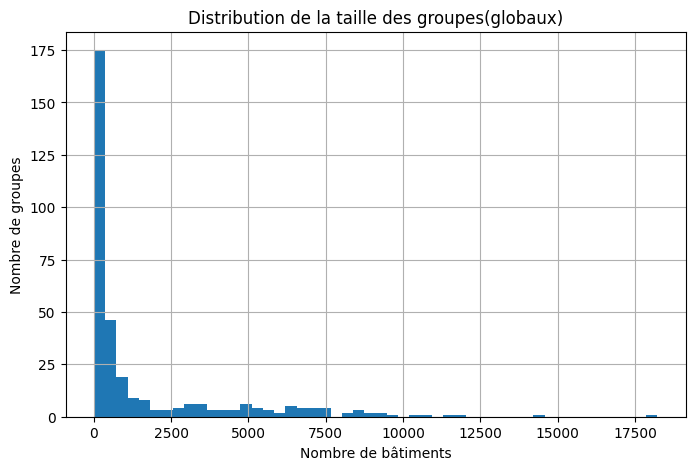

Nombre total de groupes : 112
Groupes avec moins de 2 observations : 0
Groupes avec moins de 5 observations : 0
Groupes avec moins de 10 observations : 0
Groupes avec moins de 20 observations : 0


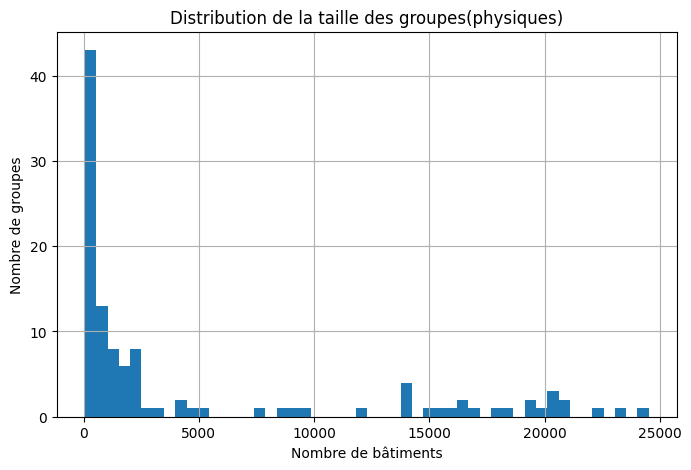

In [ ]:
#============================================================
# Vérification de la distribution des groupes de stratification (globales et physiques)
#============================================================

#globales
print("Nombre total de groupes :", len(group_sizes))

print("Groupes avec moins de 2 observations :",
      (group_sizes < 2).sum())

print("Groupes avec moins de 5 observations :",
      (group_sizes < 5).sum())

print("Groupes avec moins de 10 observations :",
      (group_sizes < 10).sum())

print("Groupes avec moins de 20 observations :",
      (group_sizes < 20).sum())

plt.figure(figsize=(8,5))

group_sizes.hist(bins=50)

plt.xlabel("Nombre de bâtiments")
plt.ylabel("Nombre de groupes")
plt.title("Distribution de la taille des groupes(globaux)")

plt.show()


#physiques
print("Nombre total de groupes :", len(group_sizes_physical))

print("Groupes avec moins de 2 observations :",
      (group_sizes_physical < 2).sum())

print("Groupes avec moins de 5 observations :",
      (group_sizes_physical < 5).sum())

print("Groupes avec moins de 10 observations :",
      (group_sizes_physical < 10).sum())

print("Groupes avec moins de 20 observations :",
      (group_sizes_physical < 20).sum())

plt.figure(figsize=(8,5))

group_sizes_physical.hist(bins=50)

plt.xlabel("Nombre de bâtiments")
plt.ylabel("Nombre de groupes")
plt.title("Distribution de la taille des groupes(physiques)")

plt.show()

In [ ]:
#=============================================================
# fussion des groupes rares en un seul groupe "RARE"
#============================================================

#globales
counts = strat["stratum"].value_counts()
rare_groups = counts[counts < 10].index

strat["stratum"] = strat["stratum"].replace(rare_groups, "RARE")


#physiques
counts_physical = strat_physical["strata"].value_counts()
rare_groups_physical = counts_physical[counts_physical < 10].index  

strat_physical["strata"] = strat_physical["strata"].replace(rare_groups_physical, "RARE")


In [ ]:
#============================================================
# Split train/test avec stratification
#============================================================

#globales
idx = np.arange(len(X))

idx_train, idx_test = train_test_split(
    idx,
    test_size=0.2,
    random_state=42,
    stratify=strat["stratum"]
)
#physiques
idx_physical = np.arange(len(X_physical))

idx_train_physical, idx_test_physical = train_test_split(
    idx_physical,
    test_size=0.2,
    random_state=42,
    stratify=strat_physical["strata"]
)


print(strat.iloc[idx_train]["stratum"].value_counts(normalize=True).head())
print(strat.iloc[idx_test]["stratum"].value_counts(normalize=True).head())
print(strat_physical.iloc[idx_train_physical]["strata"].value_counts(normalize=True).head())
print(strat_physical.iloc[idx_test_physical]["strata"].value_counts(normalize=True).head())

stratum
0_1_0_Electricity    0.033134
0_0_0_Electricity    0.026004
2_0_2_Natural Gas    0.021706
3_0_2_Natural Gas    0.021088
2_0_2_Electricity    0.019317
Name: proportion, dtype: float64
stratum
0_1_0_Electricity    0.033138
0_0_0_Electricity    0.026001
2_0_2_Natural Gas    0.021710
3_0_2_Natural Gas    0.021092
2_0_2_Electricity    0.019319
Name: proportion, dtype: float64
strata
0_0_0    0.044573
1_0_0    0.041950
2_0_0    0.040229
1_0_2    0.037809
1_1_0    0.037488
Name: proportion, dtype: float64
strata
0_0_0    0.044575
1_0_0    0.041956
2_0_0    0.040229
1_0_2    0.037811
1_1_0    0.037493
Name: proportion, dtype: float64


In [ ]:
X_train_f, X_test = train_test_split(
    X,
    test_size=0.2,
    stratify=strat["stratum"],
    random_state=42
)

Y_train_f = Y.loc[X_train_f.index]
Y_test = Y.loc[X_test.index]

X_train_physical_f, X_test_physical = train_test_split(
    X_physical,
    test_size=0.2,
    stratify=strat_physical["strata"],
    random_state=42
)
Y_train_physical_f = Y.loc[X_train_physical_f.index]
Y_test_physical = Y.loc[X_test_physical.index]

In [ ]:
print("X utilisé :", X_train_f.shape)
print("Y utilisé :", Y_train_f.shape)

print("Même index ?", X_train_f.index.equals(Y_train_f.index))

print("Nombre lignes X :", len(X_train_f))
print("Nombre lignes Y :", len(Y_train_f))

X utilisé : (439976, 107)
Y utilisé : (439976, 5)
Même index ? True
Nombre lignes X : 439976
Nombre lignes Y : 439976


In [ ]:
#============================================================
# Split the training set into training and validation sets
#============================================================

#globales
X_train, X_val, Y_train, Y_val = train_test_split(
    X_train_f,
    Y_train_f,
    test_size=0.2,
    random_state=42
)
#physiques
X_train_physical, X_val_physical, Y_train_physical, Y_val_physical = train_test_split(
    X_train_physical_f,
    Y_train_physical_f,
    test_size=0.2,
    random_state=42,
              
)



In [ ]:
results_dummy = {}

for target in Y.columns:

    median = Y_train[target].median()
    y_pred = np.full(len(Y_test), median)

    results_dummy[target] = {
        "RMSE": np.sqrt(mean_squared_error(Y_test[target], y_pred)),
        "MAE": mean_absolute_error(Y_test[target], y_pred),
        "R2": r2_score(Y_test[target], y_pred)
    }

pd.DataFrame(results_dummy).T


,RMSE,MAE,R2
out.electricity.total.energy_consumption..kwh,8851.434490,5976.310358,-0.056077
out.natural_gas.total.energy_consumption..kwh,18245.998693,10362.439949,-0.255198
out.fuel_oil.total.energy_consumption..kwh,7168.887836,1277.618526,-0.032803
out.propane.total.energy_consumption..kwh,6313.329287,1111.424763,-0.031983
out.emissions.total.lrmer_mid_case_25..co2e_kg,4644.262700,3258.194809,-0.072657


In [ ]:
models = {}
predictions = {}
results = {}

for target in Y.columns:

    print(f"\n========== {target} ==========")

    models[target] = lgb.LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=63,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1,
        reg_lambda=5,
        random_state=42
    )

    models[target].fit(
        X_train,
        Y_train[target],
        eval_set=[(X_val, Y_val[target])],
        callbacks=[lgb.early_stopping(100, verbose=False)]
    )

    models[target] = models[target]

    y_pred = models[target].predict(X_test)
    predictions[target] = y_pred

    results[target] = {
        "RMSE": np.sqrt(mean_squared_error(Y_test[target], y_pred)),
        "MAE": mean_absolute_error(Y_test[target], y_pred),
        "R2": r2_score(Y_test[target], y_pred)
    }



========== out.electricity.total.energy_consumption..kwh ==========
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,017759 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1322
[LightGBM] [Info] Number of data points in the train set: 351980, number of used features: 107
[LightGBM] [Info] Start training from score 11758,366880

========== out.natural_gas.total.energy_consumption..kwh ==========
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,018578 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1322
[LightGBM] [Info] Number of data points in the train set: 351980, number of used features: 107
[LightGBM] [Info] Start training from score 10581,448888

========== out.fuel_oil.total.energy_

In [ ]:
models_physical = {}
predictions_physical = {}
results = {}

for target in Y.columns:

    print(f"\n========== {target} ==========")

    models_physical[target] = lgb.LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=63,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1,
        reg_lambda=5,
        random_state=42
    )

    models_physical[target].fit(
        X_train_physical,
        Y_train_physical[target],
        eval_set=[(X_val_physical, Y_val_physical[target])],
        callbacks=[lgb.early_stopping(100, verbose=False)]
    )

    y_pred_physical = models_physical[target].predict(X_test_physical)
    predictions_physical[target] = y_pred_physical

    results[target] = {
        "RMSE": np.sqrt(mean_squared_error(Y_test_physical[target], y_pred_physical)),
        "MAE": mean_absolute_error(Y_test_physical[target], y_pred_physical),
        "R2": r2_score(Y_test_physical[target], y_pred_physical)
    }



========== out.electricity.total.energy_consumption..kwh ==========
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,013575 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2322
[LightGBM] [Info] Number of data points in the train set: 351980, number of used features: 82
[LightGBM] [Info] Start training from score 11753,307594

========== out.natural_gas.total.energy_consumption..kwh ==========
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,015162 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2322
[LightGBM] [Info] Number of data points in the train set: 351980, number of used features: 82
[LightGBM] [Info] Start training from score 10584,929320

========== out.fuel_oil.total.energy_co

In [ ]:
results_pct = {}

for target in Y.columns:
    y_true = Y_test[target]
    y_pred = predictions[target]

    mean = y_true.mean()
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    results_pct[target] = {
        "RMSE": rmse,
        "Erreur RMSE_%": rmse / mean * 100,
        "MAE": mae,
        "Erreur MAE_%": mae / mean * 100,
        "R2": r2_score(y_true, y_pred),
    }

results_df = (
    pd.DataFrame(results_pct)
    .T
    .sort_values("RMSE", ascending=True)
)
results_df

,RMSE,Erreur RMSE_%,MAE,Erreur MAE_%,R2
out.emissions.total.lrmer_mid_case_25..co2e_kg,1331.910380,24.532123,710.739293,13.090929,0.911778
out.electricity.total.energy_consumption..kwh,3395.428688,28.921091,1663.533649,14.169406,0.844598
out.fuel_oil.total.energy_consumption..kwh,4121.621448,322.601885,955.724990,74.805192,0.658610
out.propane.total.energy_consumption..kwh,4261.642042,383.439544,1115.465782,100.363589,0.529771
out.natural_gas.total.energy_consumption..kwh,5896.090356,55.587294,2867.997421,27.038971,0.868929


In [ ]:
results_pct_physical = {}

for target in Y.columns:
    y_true = Y_test_physical[target]
    y_pred_physical = predictions_physical[target]

    mean = y_true.mean()
    rmse = np.sqrt(mean_squared_error(y_true, y_pred_physical))
    mae = mean_absolute_error(y_true, y_pred_physical)

    results_pct_physical[target] = {
        "RMSE": rmse,
        "Erreur RMSE_%": rmse / mean * 100,
        "MAE": mae,
        "Erreur MAE_%": mae / mean * 100,
        "R2": r2_score(y_true, y_pred_physical),
    }

results_df_physical = (
    pd.DataFrame(results_pct_physical)
    .T
    .sort_values("RMSE", ascending=True)
)
results_df_physical

,RMSE,Erreur RMSE_%,MAE,Erreur MAE_%,R2
out.emissions.total.lrmer_mid_case_25..co2e_kg,1528.165238,28.162399,871.893827,16.068041,0.884941
out.electricity.total.energy_consumption..kwh,3578.544471,30.486261,1862.132508,15.863840,0.825452
out.fuel_oil.total.energy_consumption..kwh,4172.614053,327.668476,995.849002,78.202374,0.651418
out.propane.total.energy_consumption..kwh,4337.931688,394.099074,1150.724497,104.542785,0.503077
out.natural_gas.total.energy_consumption..kwh,6425.098168,60.549594,3312.134462,31.213282,0.846314
